# Resolução do desafio voxar 
**Desafio - Iniciação Científica Voxar em IA 2026**

---

## Índice

1. [Identificação da Abordagem](#1)
2. [Configurações globais do colab](#2)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import cv2 # Para analisar o brilho/contraste das imagens q nem escrito no pdf da Voxar
from PIL import Image
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from tqdm import tqdm # Barra de progresso para verificar o treinamento

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve

<a id='1'></a>
## 1. Identificação da Abordagem

### Natureza do Problema

Classificação supervisionada de imagens em **3 classes de superfície**:

- **Classe 1**: Asphalt        | Asfalto, superfície uniforme
- **Classe 2**: Belgian_blocks | Paralelepípedos ou blocos de granito
- **Classe 3**: Offroad        | Superfície não pavimentada(terra, cascalho, areia...)

### Desafios Antecipados

- **Desbalanceamento severo**: o pdf enviado explica que o dataset está altamente desbalanceado, logo os modelos terão uma tendência a ignorar classes minoritárias sem intervenção explícita.

- **Variações de captura**: iluminação variável (chuva, noite, sol direto), múltiplos dispositivos de captura e ângulos de câmera.

- **Ambiguidade visual**: asphalt molhado pode assemelhar-se a belgian_blocks; offroad com lama pode parecer asphalt escuro.

### Abordagem Escolhida: Transfer Learning com ResNet50

**Justificativa**: a rede ResNet50 pré-treinada no ImageNet possui representações de textura, bordas e padrões, o que eu espero que consiga diferenciar as 3 classes. A ideia é que o fine-tuning parcial seja superior ao treino do zero quando o dataset é pequeno e desbalanceado. O uso do ResNet50 também está com base no seguinte artigo <a href='https://arxiv.org/abs/2010.11929'>An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale</a> que indica que esse modelo dá bons resultados em datasets com poucas imagens.

**Estratégia de 2 estágios**:
1. *Feature Extraction*: backbone congelado; só a cabeça FC é treinada.
2. *Fine-Tuning*: descongela camadas finais com lr reduzido para ajuste fino ao domínio.

**Tratamento do desbalanceamento (dupla estratégia)**:
- `WeightedRandomSampler`: força distribuição equilibrada nos batches.
- `CrossEntropyLoss` com pesos de classe: penaliza mais os erros nas classes raras.

### Bibliotecas Utilizadas
- **PyTorch**: modelo, treinamento, DataLoader
- **scikit-learn**: métricas (balanced accuracy, F1, report, confusion matrix)
- **matplotlib / seaborn**: visualizações
- **numpy / pandas**: manipulação de dados

<a id='2'></a>
# 2. Configurações globais do colab

In [3]:
config = {
    'data_dir': '/content/drive/MyDrive/datasets/dataset_voxar',
    'batch_size': 32,
    'num_workers': 2,
    'num_epochs': 30,
    'learning_rate': 0.0001,
    'device': 'cuda' if torch.cuda.is_available() else "cpu",
    'model_save.pth' : 'modelo_colab.pth' # Mudar pra cada modelo que eu treine
}

In [4]:
device = torch.device(config['device'])
device

device(type='cpu')

<h1>EDA - Análise Explorativa de Dados 📊</h1>


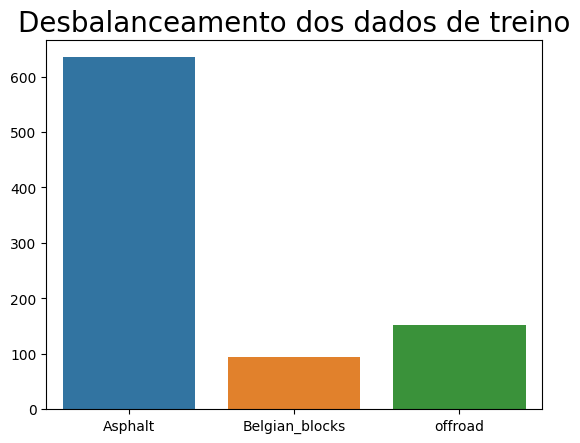

In [ ]:
quantidade_asphalt = len(os.listdir(config['data_dir']+'/train/asphalt'))
quantidade_belgian = len(os.listdir(config['data_dir']+'/train/belgian_blocks'))
quantidade_offroad = len(os.listdir(config['data_dir']+'/train/offroad'))

train_size = pd.DataFrame.from_dict({
    'Asphalt': [quantidade_asphalt],
    'Belgian_blocks': [quantidade_belgian],
    'Offroad': [quantidade_offroad]
})

grafico_em_barras = sns.barplot(data=train_size)
grafico_em_barras.set_title('Análise de desbalanceamento dos dados', fontsize=20)

for barra in grafico_em_barras.patches:
  altura_barra = barra.get_height()

  grafico_em_barras.annotate(f'{int(altura_barra)}', 
                            (barra.get_x()+ barra.get_width()/2, altura_barra),
                            ha='center', 
                            va='bottom',
                            fontsize=12,)

plt.show()

In [ ]:
def analyze_images(data_dir, quantidade_amostras=200):
  classes = ['asphalt', 'belgian_blocks', 'offroad']
  path = data_dir+'/train'

  all_images = []

  for classe in classes:
    path_class = path + '/' + classe
    name_archives = os.listdir(path_class) # Listar todos os arqiuvos

    for name_arc in name_archives:
      all_images.append(path_class + '/' + name_arc)

  random.shuffle(all_images) # Embaralhar as imagens de acordo com a seed lá do início
  samples_img = all_images[:quantidade_amostras] # Pega as 100 primeiras imagens dentro da ordem aleatória do random.shuffle

  widths = []  # largura 
  heights = [] # altura

  for name_img in samples_img:
    img = Image.open(name_img)
    width_img, height_img = img.size

    widths.append(width_img) # Descobrir os pixels/dimensão da imagem, planejo fazer um resize, caso necessário.
    heights.append(height_img)

  # Criação do gráfico a partir dos dados
  plt.figure(figsize=(8,6))
  plt.scatter(widths, heights, color='coral', alpha=0.5) # alpha=0.5 é pra deixar meio transparente meio opaco
  plt.title('Dimensões das imagens(Largura x altura)', fontsize=14)
  plt.xlabel('Largura', fontsize=12)
  plt.ylabel('Altura', fontsize=12)
  plt.grid(True)
  plt.show()

  print()
  print('-'*55)
  print(' Informações das dimensões das imagens:')
  print()
  print(f'Largura mínima: {min(widths)} px')
  print(f'Largura máxima: {max(widths)} px')
  
  print(f'\nAltura mínima: {min(heights)}px')
  print(f'Altura máxima: {max(heights)}px')

  print(f'\nMédia de largura: {np.mean(widths):.0f} px')
  print(f'Média de altura: {np.mean(heights):.0f} px')
  print('-' * 55)


analyze_images(config['data_dir'])



In [ ]:
def extreme_analysis_images(data_dir, quantidade_amostras=5)
  # ESsa primeira parte só dei ctrl c ctrl v da função anterior
  classes = ['asphalt', 'belgian_blocks', 'offroad']
  path = data_dir+'/train'

  all_images = []

  for classe in classes:
    path_class = path + '/' + classe
    name_archives = os.listdir(path_class) # Listar todos os arqiuvos

    for name_arc in name_archives:
      all_images.append(path_class + '/' + name_arc)

  random.shuffle(all_images) # Embaralhar as imagens de acordo com a seed lá do início
  samples_to_analyze = all_images[:quantidade_amostras] # Pega as 100 primeiras imagens dentro da ordem aleatória do random.shuffle

  #A partir daqui o código diferencia da função passada.

  # Calcular o brilho médio da imagem e colocá-la numa ordem da mais escura até a mais clara
  brightness_list = []

  for name_img in samples_to_analyze:
    img = Image.open(name_img)

    gray_image = img.convert('L') # Converter imagem em preto e branco numa escala cinzenta
    array_px = np.array(gray_image)

    medium_brightness = np.mean(array_px)

    brightness_list.append((name_img, medium_brightness)) # armazena caminho e brilho juntos

  brightness_list.sort(key=lambda x: x[1]) # dar sort de acordo com o valor de brilho médio, imagens mais escuras -> imagens mais claras

  dark_imgs = brightness_list[:quantidade_amostras]
  light_imgs = brightness_list[-quantidade_amostras:]

  # Configuração do gráfico e de plotagem

  fig, axs = plt.subplots(2, quantidade_amostras, figsize=(15,7)) # figuras e eixos
  fig.suptitle('Imagens mais escuras x Imagens mais claras', fontsize=16)

  for indice in range(quantidade_amostras):
      # Desenhando as imagens escuras na primeira linha (índice 0)
      caminho_escura = imagens_mais_escuras[indice][0]
      imagem_escura = Image.open(caminho_escura)
      eixos[0, indice].imshow(imagem_escura)
      nome_da_classe_escura = caminho_escura.split('/')[-2] # Pega o nome da pasta
      eixos[0, indice].set_title(f"Escura: {nome_da_classe_escura}")
      eixos[0, indice].axis('off') # Esconde os eixos de números
      
      # Desenhando as imagens claras na segunda linha (índice 1)
      caminho_clara = imagens_mais_claras[indice][0]
      imagem_clara = Image.open(caminho_clara)
      eixos[1, indice].imshow(imagem_clara)
      nome_da_classe_clara = caminho_clara.split('/')[-2]
      eixos[1, indice].set_title(f"Clara: {nome_da_classe_clara}")
      eixos[1, indice].axis('off')
      
  plt.tight_layout()
  plt.show()

visualizar_condicoes_extremas(config['data_dir'])

<h1>Tratamento de dados</h1>

In [ ]:
normal_mean = [0.485, 0.456, 0.406] # Padrões do ImageNet
standard_mean = [0.229, 0.224, 0.225] 

treino_transforms = transforms.Compose([
    transforms.Resize((224 + 48, 224 + 48)), # pxs da imagem
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(normal_mean, standard_mean),
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(standard_mean, normal_mean),
])